## 1. Постановка прикладної задачі регресії

**(1) Предметна область**  
Набір даних належить до галузі ботаніки, рослинної таксономії та біологічної морфометрії — наукового напряму, що вивчає кількісні просторові характеристики біологічних об'єктів для аналізу їхньої мінливості та еволюції.

**(2) Об'єкт або процес, що описується даними**  
Об'єктом дослідження є окремий екземпляр квітки роду Ірис (*Iris*). Дані описують морфологічну будову квітки, фіксуючи геометричні розміри (довжину та ширину) її чашолистків (*sepals*) і пелюсток (*petals*), а також біологічний вид рослини (*Setosa*, *Versicolor* або *Virginica*).

**(3) Цільова змінна**  
Цільовою змінною є `sepal_width` — ширина чашолистка квітки, виміряна у сантиметрах.

**(4) Обґрунтування задачі регресії**  
Задача класифікується як регресія, оскільки цільова змінна (`sepal_width`) є неперервною (кількісною) числовою величиною. Мета алгоритму — спрогнозувати дійсне число в певному діапазоні (наприклад, від 2.0 до 4.5 см), а не віднести об'єкт до дискретної категорії чи класу.

**(5) Практичний зміст передбачення**  
Практичний зміст полягає у побудові математичної функції, яка дозволяє з високою точністю реконструювати (обчислити) ширину чашолистка конкретної квітки, спираючись на інші її відомі пропорції (довжину чашолистка, розміри пелюсток) та генетичну належність (вид).

**(6) Практична цінність результату**  
Подібна регресійна модель має кілька практичних застосувань у ботаніці та агропромисловості:
* **Цифрова реконструкція пошкоджених зразків:** Під час оцифрування історичних гербаріїв або роботи з частково пошкодженими польовими зразками (де чашолисток відірваний або деформований), модель дозволяє достовірно відновити відсутній вимір для збереження цілісності бази даних.
* **Біоіндикація та екологічний моніторинг (виявлення аномалій):** Якщо фактична ширина чашолистка рослини значно відхиляється від значення, передбаченого моделлю (еталонної норми), це є прямим індикатором екологічного стресу, нестачі нутрієнтів, наявності захворювань або генетичних мутацій.
* **Автоматизація в промисловій селекції:** Алгоритм може використовуватися в системах комп'ютерного зору на етапі відбраковування: модель швидко вираховує очікувані ідеальні пропорції квітки та порівнює їх із фактичними, автоматизуючи контроль сортової якості без ручних замірів.

## 2. Аналіз індивідуального набору даних (EDA)

Для виконання первинного аналізу завантажимо набір даних Iris та дослідимо його базові характеристики: розмірність, типи даних, наявність пропусків і дублікатів.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Завантаження набору даних
iris = load_iris(as_frame=True)
df = iris.frame

# Зміна назв стовпців для зручності
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
# Перетворення числового коду виду на текстову категорію для наочності
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['species'].map(species_map)

# Виведення базової інформації
print("--- Розмірність та типи даних ---")
df.info()

print("\n--- Описова статистика ---")
display(df.describe())

print("\n--- Пропуски та дублікати ---")
print(f"Кількість пропусків:\n{df.isna().sum()}\n")
print(f"Кількість повних дублікатів: {df.duplicated().sum()}")

--- Розмірність та типи даних ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Описова статистика ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Пропуски та дублікати ---
Кількість пропусків:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Кількість повних дублікатів: 1


### 2.1. Візуалізація цільової змінної та структури даних

Побудуємо гістограму розподілу цільової змінної `sepal_width`, а також Boxplot для оцінки наявності потенційних аномалій (викидів) у розрізі видів.

C:\Users\Yaroslav\AppData\Local\Temp\ipykernel_1180\937409999.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='sepal_width', palette=palette, ax=axes[1])


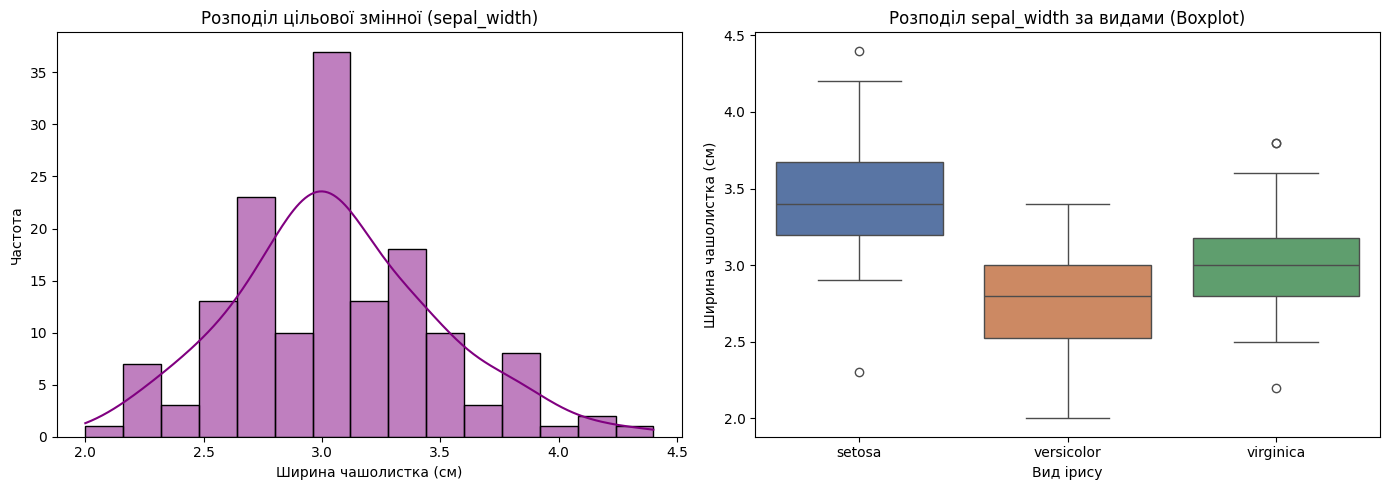

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

# Гістограма цільової змінної
sns.histplot(data=df, x='sepal_width', kde=True, bins=15, color='purple', ax=axes[0])
axes[0].set_title('Розподіл цільової змінної (sepal_width)')
axes[0].set_xlabel('Ширина чашолистка (см)')
axes[0].set_ylabel('Частота')

# Boxplot для виявлення аномалій у розрізі видів
sns.boxplot(data=df, x='species', y='sepal_width', palette=palette, ax=axes[1])
axes[1].set_title('Розподіл sepal_width за видами (Boxplot)')
axes[1].set_xlabel('Вид ірису')
axes[1].set_ylabel('Ширина чашолистка (см)')

plt.tight_layout()
plt.show()

### 2.2. Висновки первинного аналізу даних

На основі отриманих метрик та візуалізацій зроблено такі висновки:
1. **Кількість об'єктів:** 150 екземплярів.
2. **Кількість вхідних ознак:** 4 предиктори (`sepal_length`, `petal_length`, `petal_width`, `species`).
3. **Типи ознак:** Три ознаки є числовими дійсними (`float64`), одна — об'єктною/категоріальною (`object`).
4. **Діапазон значень цільової змінної (`sepal_width`):** Від мінімального 2.0 см до максимального 4.4 см (середнє значення ~3.06 см). Розподіл візуально близький до нормального.
5. **Наявність пропущених значень:** Пропусків (`NaN` або `Null`) немає в жодній колонці (0%).
6. **Наявність дублікатів:** Виявлено 1 повний дублікат. Враховуючи специфіку даних (округлення до міліметрів), це ймовірний природний збіг розмірів двох різних квіток, а не помилка введення.
7. **Наявність потенційно аномальних значень:** На загальному графіку та Boxplot для виду *Setosa* помітні точки поза "вусами" (> 4.0 см та < 2.2 см). Однак ботанічний контекст вказує, що це природна мінливість, а не помилкові викиди.
8. **Наявність категоріальних ознак:** Присутня одна номінальна категоріальна ознака — `species` (вид ірису).
9. **Неінформативні або службові стовпці:** Службові стовпці (на кшталт `Id` чи `Index`) відсутні. Усі наявні ознаки несуть смислове навантаження.

## 3. Планування експерименту

Для забезпечення відтворюваності та об'єктивності оцінки, план експерименту формулюється **до** початку навчання моделей та розрахунку метрик на тестових даних.

1. **Спосіб поділу даних:** Дані будуть розділені на навчальну (Train) та тестову (Test) вибірки у пропорції **80% на 20%** (`test_size=0.2`). Це стандартне співвідношення, яке залишає 120 об'єктів для стабільного навчання та 30 об'єктів для фінальної перевірки, що є достатнім для цього невеликого датасету. Для забезпечення репрезентативності видів буде використано стратифікацію за категорією `species` (якщо розбиття застосовується після OHE — стратифікація за вихідним масивом класів).
2. **Процедура крос-валідації:** Оскільки датасет невеликий (150 об'єктів), буде використано **K-Fold крос-валідацію** з $K=5$ на навчальній вибірці. Це дозволить навчити та перевірити моделі на 5 різних підмножинах (по 96 об'єктів у fold-train та 24 у fold-val), що мінімізує ризик випадкового вдалого розбиття.
3. **Baseline-модель:** Як базову модель (baseline) обрано `DummyRegressor` із стратегією передбачення медіанного значення (`strategy='median'`). Це дозволить оцінити, чи кандидатні моделі взагалі здатні знаходити математичні закономірності у даних краще, ніж "наївний" прогноз.
4. **Кандидатні моделі:** 
   * `LinearRegression` (Класична множинна лінійна регресія) — для перевірки наявності простих лінійних зв'язків.
   * `Ridge` (Лінійна регресія з L2-регуляризацією) — для боротьби з потенційною мультиколінеарністю.
   * `RandomForestRegressor` (Випадковий ліс) — для уловлювання нелінійних залежностей та складної взаємодії ознак (зокрема категорій видів).
5. **Метрики порівняння:**
   * **RMSE** (Root Mean Squared Error) — основна метрика, оскільки вона інтерпретується в тих самих одиницях, що й цільова змінна (сантиметри).
   * **$R^2$** (Коефіцієнт детермінації) — для оцінки того, яку частку дисперсії цільової змінної пояснює модель.
6. **Критерій вибору фінальної моделі:** Фінальною буде обрана модель, яка продемонструє найвищий середній бал $R^2$ та найнижчий середній RMSE за результатами 5-Fold крос-валідації на навчальній вибірці. Тестова вибірка (20%) буде використана **лише один раз** наприкінці для підтвердження того, що обрана модель не перенавчилася.

## 4. Попередня обробка даних

Відповідно до плану експерименту, спочатку виконаємо поділ даних на навчальну (80%) та тестову (20%) вибірки. Усі трансформації, параметри яких залежать від даних (наприклад, середнє значення для масштабування), будуть "навчатися" (fit) виключно на тренувальній вибірці, щоб уникнути витоку даних (data leakage).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Виокремлення матриці ознак (X) та цільової змінної (y)
X = df.drop(columns=['sepal_width'])
y = df['sepal_width']

# Поділ на train та test (80/20) із фіксацією random_state для відтворюваності
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X['species']
)

# Визначення колонок за типами
numeric_features = ['sepal_length', 'petal_length', 'petal_width']
categorical_features = ['species']

# Створення ColumnTransformer для паралельної обробки різних типів колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # На випадок, якщо з'являться додаткові стовпці
)

print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір навчальної вибірки: (120, 4)
Розмір тестової вибірки: (30, 4)


### Обґрунтування операцій попередньої обробки

**Які перетворення були застосовані та чому:**
1. **Кодування категоріальних змінних (One-Hot Encoding):** Застосовано до ознаки `species` із параметром `drop='first'` (щоб уникнути мультиколінеарності — "dummy variable trap"). Це необхідно, оскільки більшість регресійних алгоритмів (наприклад, лінійна регресія) працюють лише з числовими матрицями, а вид ірису є номінальною текстовою категорією.
2. **Масштабування числових ознак (StandardScaler):** Застосовано до `sepal_length`, `petal_length`, `petal_width`. Зведення ознак до нульового середнього та одиничної дисперсії є критично важливим для моделей із регуляризацією (наприклад, Ridge), оскільки алгоритм штрафуватиме ознаки з більшим масштабом сильніше, якщо їх не стандартизувати.

**Які операції НЕ застосовувалися і чому:**
1. **Обробка пропущених значень (Imputation):** Не застосовувалася, оскільки первинний аналіз (EDA) показав 0% пропусків у наборі даних.
2. **Видалення дублікатів:** Не застосовувалося. Знайдений 1 дублікат є природним збігом габаритів двох різних квіток, виміряних із точністю до міліметра. Його видалення спотворило б природний розподіл даних.
3. **Видалення неінформативних стовпців:** Усі наявні предиктори безпосередньо впливають на морфологію квітки (немає стовпців типу ID або дат), тому жоден з них не видалено.
4. **Створення нових ознак / Поліноміальні перетворення:** Не застосовувалися на базовому етапі для збереження простоти та інтерпретованості моделі. (Може бути додано на етапі покращення результатів, якщо базових ознак виявиться недостатньо).

## 5. Побудова базової моделі (Baseline)

Створимо пайплайн із базовою моделлю `DummyRegressor`, яка завжди прогнозує середнє значення цільової змінної (`strategy='mean'`). Ця модель ігнорує всі вхідні ознаки. Її результати є мінімальним порогом — будь-яка справжня модель машинного навчання повинна показати суттєво меншу похибку (RMSE) та вищий $R^2$ (який для `mean` стратегії теоретично дорівнюватиме $\approx 0$).

In [6]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# Створення пайплайну: передобробка + базова модель
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

# Проведення 5-Fold крос-валідації лише на навчальній вибірці
cv_results_baseline = cross_validate(
    baseline_pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring=['neg_root_mean_squared_error', 'r2'],
    return_train_score=False
)

# Розрахунок середніх значень метрик (інвертуємо знак для RMSE)
baseline_rmse = -np.mean(cv_results_baseline['test_neg_root_mean_squared_error'])
baseline_r2 = np.mean(cv_results_baseline['test_r2'])

print("--- Результати Baseline-моделі (Cross-Validation) ---")
print(f"Середній RMSE: {baseline_rmse:.4f} см")
print(f"Середній R^2:  {baseline_r2:.4f}")

--- Результати Baseline-моделі (Cross-Validation) ---
Середній RMSE: 0.4482 см
Середній R^2:  -0.0506
